## PAIRED VS CONDITIONED

2026-06-05 14:01:08,758 - CHIMERA - INFO - Loading `CHIMERA`. GPU acceleration: False


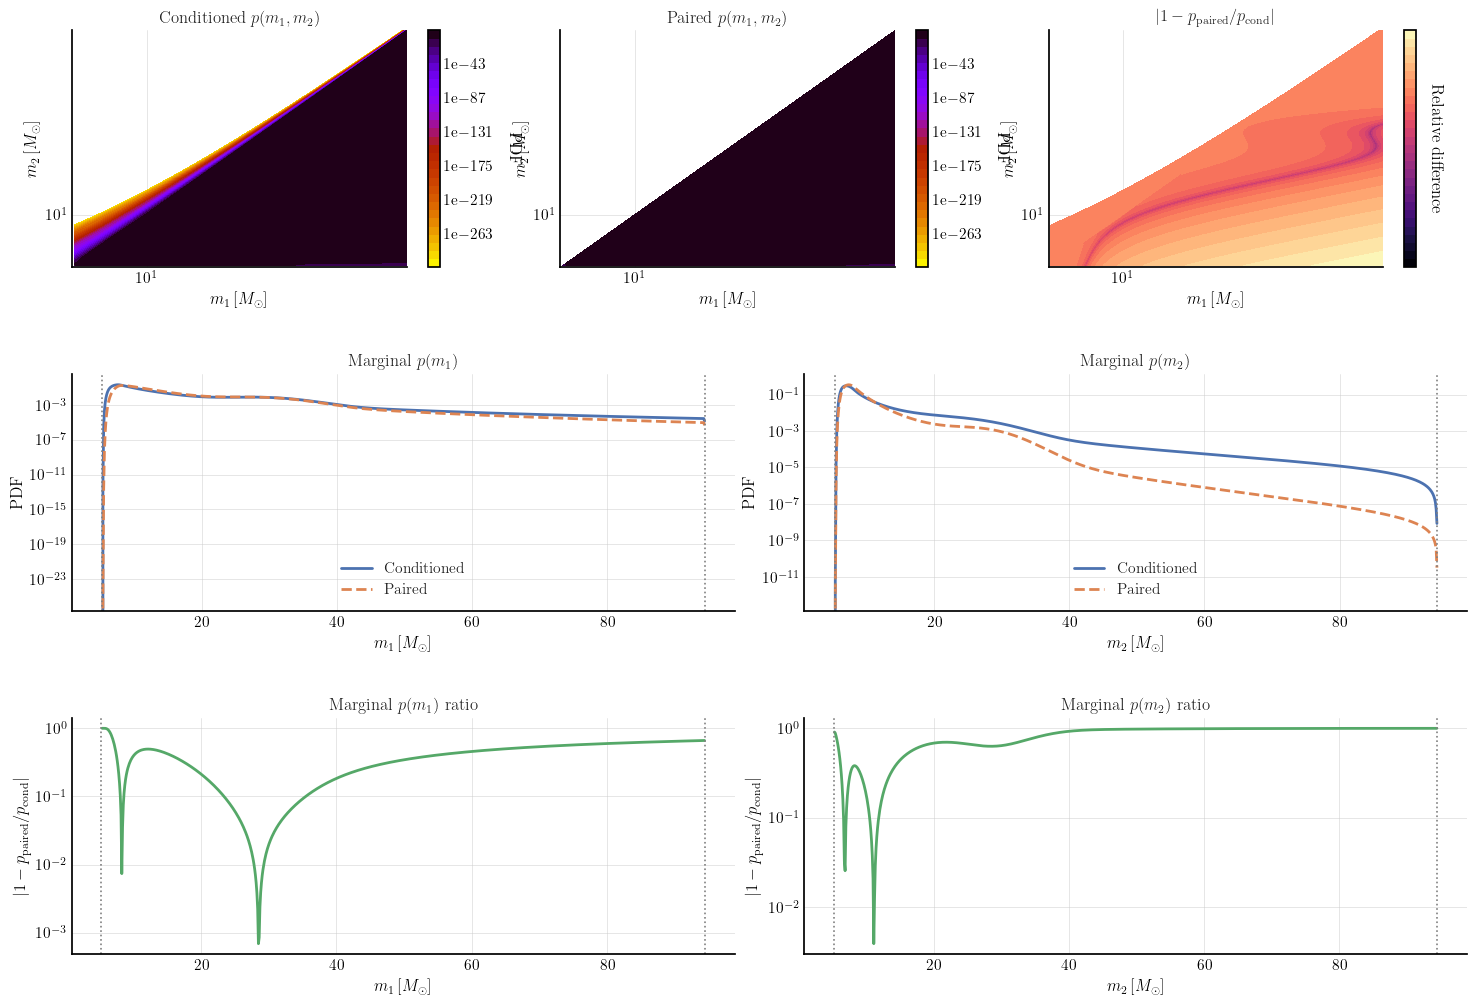

In [1]:
import os, sys
os.environ['CHIMERA_ENABLE_GPU'] = "False"
sys.path.append(os.getcwd()+'/../')
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import rc
from matplotlib.ticker import LogLocator, LogFormatter
import seaborn as sns

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_context('talk')
sns.set_theme(style="whitegrid", rc={
    "axes.spines.right": False,
    "axes.spines.top":   False,
    "xtick.direction":   "in",
    "ytick.direction":   "in",
    "axes.edgecolor":    "black",
    "xtick.color":       "black",
    "ytick.color":       "black",
    "axes.labelcolor":   "black",
    "grid.linewidth":    0.5,
    "grid.alpha":        0.7,
})
rc('font', **{'family': 'serif', 'serif': ['Times New Roman']})
rc('text', usetex=True)
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# ── Mass models ────────────────────────────────────────────────────────────
from CHIMERA.mass import pdf_joint_and_marg, p_m1m2
from CHIMERA.mass.conditioned import plp as plp_cond
from CHIMERA.mass.paired      import plp as plp_paired

# ── Shared population parameters ───────────────────────────────────────────
# (PLP defaults from O3; feel free to override)
params = dict(
    m_low       = 5.26,
    m_high      = 94.4,
    lambda_peak = 0.04,
    alpha       = 3.6,
    beta        = 1.08,
    delta_m     = 3.3,
    mu_g        = 28.6,
    sigma_g     = 5.15,
)

mass_cond   = plp_cond(**params)
mass_paired = plp_paired(**params)

# ── Evaluate joint + marginals on a shared grid ────────────────────────────
RES = (800, 800)   # (n_m1, n_m2)  – increase for publication quality

out_cond   = pdf_joint_and_marg(mass_cond,   res=RES)
out_paired = pdf_joint_and_marg(mass_paired, res=RES)

m1      = np.array(out_cond['m1'])
m2      = np.array(out_cond['m2'])
m1mesh  = np.array(out_cond['m1mesh'])
m2mesh  = np.array(out_cond['m2mesh'])

p_joint_cond   = np.array(out_cond['p_joint'])
p_joint_paired = np.array(out_paired['p_joint'])

p_m1_cond      = np.array(out_cond['p_m1_marg'])
p_m2_cond      = np.array(out_cond['p_m2_marg'])
p_m1_paired    = np.array(out_paired['p_m1_marg'])
p_m2_paired    = np.array(out_paired['p_m2_marg'])

# ── Helper: log contourf ───────────────────────────────────────────────────
def log_contourf(fig, ax, x, y, z, cmap, title, xlabel, ylabel,
                 clabel='PDF', vmin=None, vmax=None):
    z = np.where(z > 0, z, np.nan)
    if vmin is None: vmin = np.nanmin(z)
    if vmax is None: vmax = np.nanmax(z)
    levels = np.logspace(np.log10(vmin), np.log10(vmax), 30)
    cont = ax.contourf(x, y, z,
                       levels=levels, cmap=cmap,
                       norm=colors.LogNorm(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(cont, ax=ax,
                        format=LogFormatter(labelOnlyBase=False))
    cbar.set_label(clabel, rotation=270, labelpad=20)
    cbar.locator = LogLocator(subs='all')
    cbar.update_ticks()
    ax.set_title(title)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    return cont

# ── Figure layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(3, 6, height_ratios=[1, 1, 1], hspace=0.45, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0:2])   # conditioned joint
ax2 = fig.add_subplot(gs[0, 2:4])   # paired joint
ax3 = fig.add_subplot(gs[0, 4:6])   # relative difference (joint)

ax4 = fig.add_subplot(gs[1, 0:3])   # marginal p(m1)
ax5 = fig.add_subplot(gs[1, 3:6])   # marginal p(m2)

ax6 = fig.add_subplot(gs[2, 0:3])   # relative diff p(m1)
ax7 = fig.add_subplot(gs[2, 3:6])   # relative diff p(m2)

# ── Shared colour range for the two joint PDFs ────────────────────────────
_pos = np.where(np.isfinite(p_joint_cond) & (p_joint_cond > 0), p_joint_cond, np.nan)
vmin_joint = np.nanmin(_pos)
vmax_joint = np.nanmax(_pos)

# ── Row 1: joint PDFs ─────────────────────────────────────────────────────
log_contourf(fig, ax1, m1mesh, m2mesh, p_joint_cond, 'gnuplot_r',
             r'Conditioned $p(m_1, m_2)$', r'$m_1\,[M_\odot]$', r'$m_2\,[M_\odot]$',
             vmin=vmin_joint, vmax=vmax_joint)

log_contourf(fig, ax2, m1mesh, m2mesh, p_joint_paired, 'gnuplot_r',
             r'Paired $p(m_1, m_2)$', r'$m_1\,[M_\odot]$', r'$m_2\,[M_\odot]$',
             vmin=vmin_joint, vmax=vmax_joint)

rel_diff_joint = np.abs(1.0 - p_joint_paired / np.where(p_joint_cond > 0, p_joint_cond, np.nan))
log_contourf(fig, ax3, m1mesh, m2mesh, rel_diff_joint, 'magma',
             r'$|1 - p_\mathrm{paired}/p_\mathrm{cond}|$',
             r'$m_1\,[M_\odot]$', r'$m_2\,[M_\odot]$',
             clabel=r'Relative difference')

# ── Row 2: marginals ──────────────────────────────────────────────────────
for ax, x, pc, pp, lbl in [
    (ax4, m1, p_m1_cond, p_m1_paired, r'$m_1\,[M_\odot]$'),
    (ax5, m2, p_m2_cond, p_m2_paired, r'$m_2\,[M_\odot]$'),
]:
    ax.plot(x, pc, label=r'Conditioned', lw=2)
    ax.plot(x, pp, label=r'Paired',      lw=2, ls='--')
    ax.set_yscale('log')
    ax.set_xlabel(lbl)
    ax.set_ylabel('PDF')
    ax.legend(frameon=False)
    ax.axvline(params['m_low'],  ls=':', c='gray', lw=1.2)
    ax.axvline(params['m_high'], ls=':', c='gray', lw=1.2)

ax4.set_title(r'Marginal $p(m_1)$')
ax5.set_title(r'Marginal $p(m_2)$')

# ── Row 3: relative differences of marginals ──────────────────────────────
for ax, x, pc, pp, lbl in [
    (ax6, m1, p_m1_cond, p_m1_paired, r'$m_1\,[M_\odot]$'),
    (ax7, m2, p_m2_cond, p_m2_paired, r'$m_2\,[M_\odot]$'),
]:
    rd = np.abs(1.0 - pp / np.where(pc > 0, pc, np.nan))
    ax.plot(x, rd, lw=2, color='C2')
    ax.set_yscale('log')
    ax.set_xlabel(lbl)
    ax.set_ylabel(r'$|1 - p_\mathrm{paired}/p_\mathrm{cond}|$')
    ax.axvline(params['m_low'],  ls=':', c='gray', lw=1.2)
    ax.axvline(params['m_high'], ls=':', c='gray', lw=1.2)

ax6.set_title(r'Marginal $p(m_1)$ ratio')
ax7.set_title(r'Marginal $p(m_2)$ ratio')
plt.show()

         N       cond integral           ±2σ     paired integral           ±2σ
------------------------------------------------------------------------------
      1000            0.894074      8.21e-01            1.055876      7.81e-01
      1438            0.715201      5.74e-01            0.852058      5.52e-01
      2069            0.576464      4.01e-01            0.678844      3.87e-01
      2976            0.990510      8.87e-01            1.027769      6.91e-01
      4281            0.890154      6.51e-01            0.981776      5.63e-01
      6158            1.022667      6.35e-01            0.964215      4.24e-01
      8858            1.009716      4.69e-01            1.001758      3.37e-01
     12742            0.946300      3.93e-01            0.960873      2.93e-01
     18329            0.982201      3.37e-01            0.975331      2.39e-01
     26366            0.915273      2.51e-01            0.959786      1.94e-01
     37926            0.818479      1.89e-01        

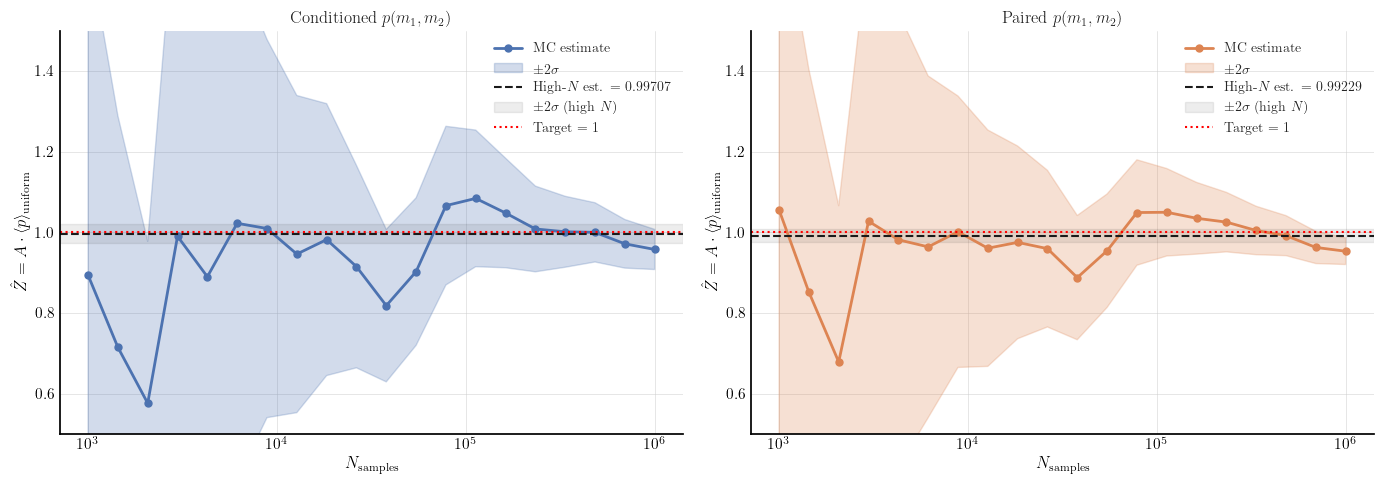

In [2]:
"""
Monte Carlo normalisation check
================================
Estimates  ∫∫ p(m1, m2) dm1 dm2  for both the conditioned and paired plp
models using plain Monte Carlo importance sampling.

Strategy
--------
We draw (m1, m2) uniformly from the rectangle [m_low, m_high]^2 and use
the estimator

    ∫∫ p dm1 dm2  ≈  A * <p(m1_i, m2_i)>_uniform
                  = (m_high - m_low)^2 * mean(p(m1_i, m2_i))

where A = (m_high - m_low)^2 is the area of the sampling rectangle.

Because p = 0 for m2 > m1 by construction, samples with m2 > m1 simply
contribute zero to the mean — no explicit masking is required.

We also run a convergence study (integral vs N_samples) to make sure the
estimate has stabilised, and report the mean ± 2σ Monte Carlo error.
"""

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_context('talk')
sns.set_theme(style="whitegrid", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "xtick.direction": "in",    "ytick.direction": "in",
    "axes.edgecolor": "black",  "xtick.color": "black",
    "ytick.color": "black",     "axes.labelcolor": "black",
    "grid.linewidth": 0.5,      "grid.alpha": 0.7,
})
rc('font', **{'family': 'serif', 'serif': ['Times New Roman']})
rc('text', usetex=True)
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# ── Models ─────────────────────────────────────────────────────────────────
from CHIMERA.mass import p_m1m2
from CHIMERA.mass.conditioned import plp as plp_cond
from CHIMERA.mass.paired      import plp as plp_paired

params = dict(
    m_low=5.26, m_high=94.4,
    lambda_peak=0.04, alpha=3.6, beta=1.08,
    delta_m=3.3, mu_g=28.6, sigma_g=5.15,
)
mass_cond   = plp_cond(**params)
mass_paired = plp_paired(**params)

m_low  = float(params['m_low'])
m_high = float(params['m_high'])
Area   = (m_high - m_low) ** 2   # area of the sampling rectangle

# ── Monte Carlo estimator ──────────────────────────────────────────────────
def mc_integral(mass, N, seed=0):
    """Return (estimate, std_error) of ∫∫ p(m1,m2) dm1 dm2."""
    key = jax.random.PRNGKey(seed)
    k1, k2 = jax.random.split(key)
    m1_s = jax.random.uniform(k1, (N,), minval=m_low, maxval=m_high)
    m2_s = jax.random.uniform(k2, (N,), minval=m_low, maxval=m_high)
    vals = p_m1m2(mass, m1_s, m2_s)          # zero where m2 > m1
    estimate = Area * jnp.mean(vals)
    stderr   = Area * jnp.std(vals) / jnp.sqrt(N)
    return float(estimate), float(stderr)

# ── Convergence study ──────────────────────────────────────────────────────
Ns = np.logspace(3, 6, 20).astype(int)   # 1 000 → 1 000 000

results = {'cond': [], 'paired': []}
errors  = {'cond': [], 'paired': []}

print(f"{'N':>10}  {'cond integral':>18}  {'±2σ':>12}  {'paired integral':>18}  {'±2σ':>12}")
print("-" * 78)
for N in Ns:
    ic, ec = mc_integral(mass_cond,   N)
    ip, ep = mc_integral(mass_paired, N)
    results['cond'].append(ic);   errors['cond'].append(ec)
    results['paired'].append(ip); errors['paired'].append(ep)
    print(f"{N:>10d}  {ic:>18.6f}  {2*ec:>12.2e}  {ip:>18.6f}  {2*ep:>12.2e}")

# ── Final high-N estimate ──────────────────────────────────────────────────
N_final = 5_000_000
ic_f, ec_f = mc_integral(mass_cond,   N_final, seed=42)
ip_f, ep_f = mc_integral(mass_paired, N_final, seed=42)

print(f"\nHigh-N estimate  (N = {N_final:,})")
print(f"  Conditioned plp :  {ic_f:.8f}  ±  {2*ec_f:.2e}  (2σ)")
print(f"  Paired      plp :  {ip_f:.8f}  ±  {2*ep_f:.2e}  (2σ)")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

labels  = [r'Conditioned $p(m_1,m_2)$', r'Paired $p(m_1,m_2)$']
keys    = ['cond', 'paired']
final   = [(ic_f, ec_f), (ip_f, ep_f)]
colors  = ['C0', 'C1']

for ax, key, lbl, (ival, ierr), col in zip(axes, keys, labels, final, colors):
    res = np.array(results[key])
    err = np.array(errors[key])

    ax.semilogx(Ns, res, 'o-', color=col, lw=2, ms=5, label='MC estimate')
    ax.fill_between(Ns, res - 2*err, res + 2*err,
                    alpha=0.25, color=col, label=r'$\pm 2\sigma$')

    # High-N reference band
    ax.axhline(ival, color='k', ls='--', lw=1.5,
               label=fr'High-$N$ est. $= {ival:.5f}$')
    ax.axhspan(ival - 2*ierr, ival + 2*ierr,
               color='k', alpha=0.08, label=fr'$\pm 2\sigma$ (high $N$)')

    # Ideal normalisation
    ax.axhline(1.0, color='red', ls=':', lw=1.5, label='Target $= 1$')

    ax.set_xlabel(r'$N_\mathrm{samples}$')
    ax.set_ylabel(r'$\hat{Z} = A \cdot \langle p \rangle_\mathrm{uniform}$')
    ax.set_title(lbl)
    ax.legend(fontsize=10, frameon=False)
    ax.set_ylim(0.5, 1.5)

plt.tight_layout()
#plt.savefig('normalization_check.pdf', bbox_inches='tight')
plt.show()

## COMPARISON WITH ICARO PAIRED MODEL

Config file loaded
Config does not allow CUPY


/home/mt/softwares/py_venv/gw-env/lib/python3.10/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/home/mt/softwares/icarogw/icarogw/priors.py:153: RuntimeWarning: overflow encountered in exp
  effe_prime[select_window] = xp.exp(xp.nan_to_num((delta_m/mprime[select_window])+(delta_m/(mprime[select_window]-delta_m))))
/home/mt/softwares/icarogw/icarogw/priors.py:585: RuntimeWarning: divide by zero encountered in log
  prob_ret 

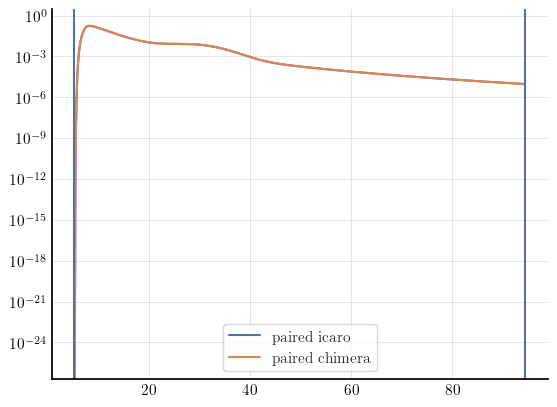

In [3]:
import sys
sys.path.append('/home/mt/softwares/icarogw')
fp=open('config.py','w')
fp.write('CUPY=False')
fp.close()
import icarogw
import matplotlib.pyplot as plt

mw = icarogw.wrappers.massprior_PowerLawPeak()
mw = icarogw.wrappers.lowSmoothedwrapper(mw)
mw = icarogw.wrappers.m1m2_paired(mw)

par_dict = mass_cond.as_dict
par_dict = {k:float(par_dict[k]) for k in par_dict.keys()}
par_dict['mmin'] = par_dict.pop('m_low')
par_dict['mmax'] = par_dict.pop('m_high')
mw.update(**par_dict)
pdf_joint_icaro = mw.pdf(m1mesh, m2mesh)
pdf_m1_marg_icaro = jnp.trapezoid(pdf_joint_icaro, x=m2, axis=0)
pdf_m1_marg_icaro /= jnp.trapezoid(pdf_m1_marg_icaro, x=m1)
pdf_m2_marg_icaro = jnp.trapezoid(pdf_joint_icaro, x=m1, axis=1)
pdf_m2_marg_icaro /= jnp.trapezoid(pdf_m2_marg_icaro, x=m2)

plt.plot(m1, pdf_m1_marg_icaro, label='paired icaro')
plt.plot(m1, p_m1_paired, label='paired chimera')
plt.axvline(par_dict['mmin'])
plt.axvline(par_dict['mmax'])
plt.legend()
plt.yscale('log')

/tmp/ipykernel_38966/1938044527.py:35: UserWarning: Log scale: values of z <= 0 have been masked
  cont = ax.contourf(
/tmp/ipykernel_38966/1938044527.py:86: RuntimeWarning: invalid value encountered in divide
  p = jnp.abs(1-p_joint_paired/pdf_joint_icaro)


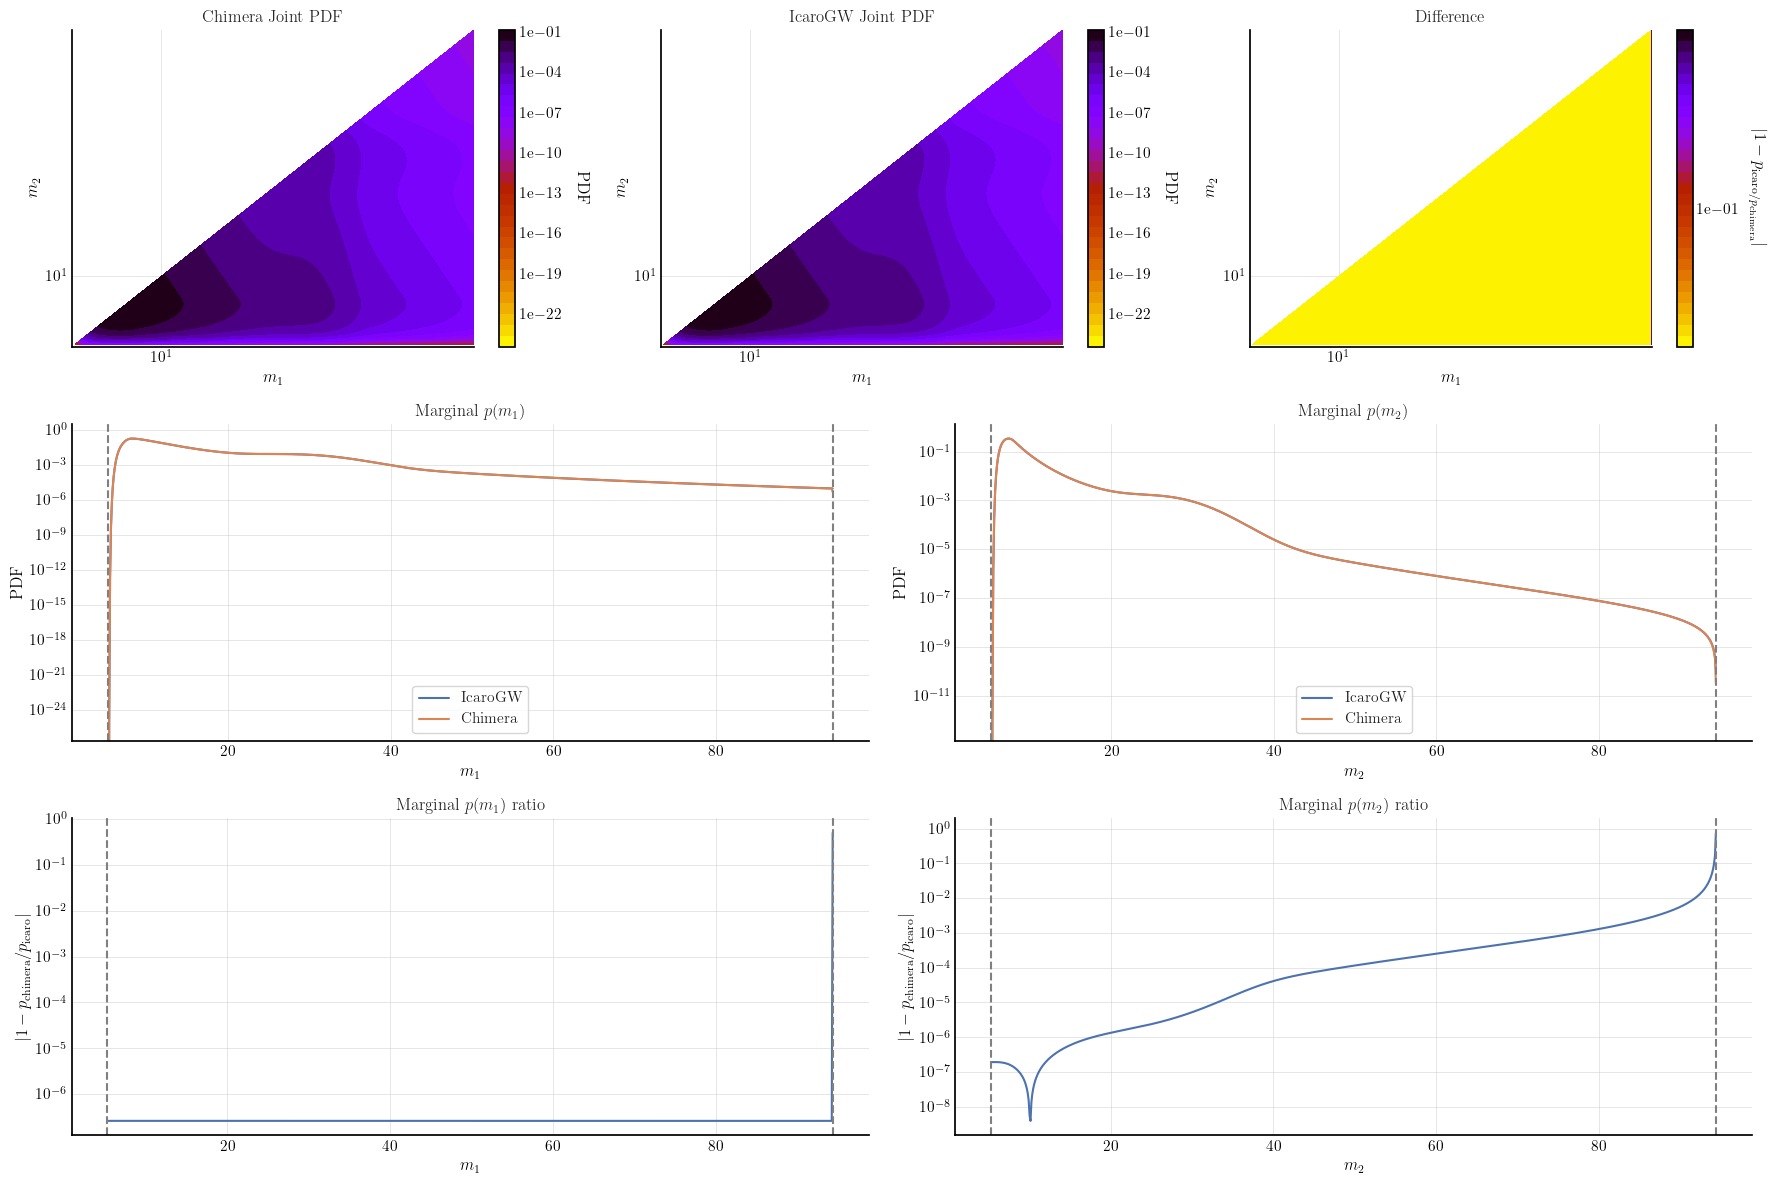

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors
from matplotlib import rc
import seaborn as sns
sns.set_context('talk')
custom_params = {
    # Spine settings (from your original)
    "axes.spines.right": False,
    "axes.spines.top": False,
    "xtick.direction": "in",  # Ticks inside
    "ytick.direction": "in",  # Ticks inside
    "axes.edgecolor": "black",  # Black spines (bottom/left)
    "xtick.color": "black",     # Black x-ticks
    "ytick.color": "black",     # Black y-ticks
    "axes.labelcolor": "black", # Black axis labels
    "grid.linewidth": 0.5,      # Thinner grid lines (default: 1.0)
    "grid.alpha": 0.7,          # Increased transparency (default: 0.5)
}

sns.set_theme(style="whitegrid", rc=custom_params)

# --- LaTeX Font Setup ---
rc('font', **{'family': 'serif', 'serif': ['Times New Roman']})
rc('text', usetex=True)  # Enable LaTeX rendering
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # For additional math symbols

from matplotlib.ticker import LogLocator, LogFormatter

def create_log_contourf(ax, x, y, z, cmap, title, xlabel, ylabel, clabel='PDF'):
  vmin = np.min(z[z > 0])
  vmax = np.max(z)
  levels = np.logspace(np.log10(vmin), np.log10(vmax), 30)
  
  cont = ax.contourf(
      x, y, z,
      levels=levels,
      cmap=cmap,
      norm=colors.LogNorm(vmin=vmin, vmax=vmax)
  )
  
  # Create colorbar with better tick formatting
  cbar = fig.colorbar(cont, ax=ax, format=LogFormatter(labelOnlyBase=False))
  cbar.set_label(clabel, rotation=270, labelpad=20)
  
  # Set ticks at powers of 10
  cbar.locator = LogLocator(subs='all')
  cbar.update_ticks()
  
  ax.set_title(title)
  ax.set_xscale('log')
  ax.set_yscale('log')
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  return cont


# Create figure with 3 rows and 6 columns
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 6, height_ratios=[1, 1, 1])

# Row 1: Three contour plots (each spanning 2 columns)
ax1 = fig.add_subplot(gs[0, 0:2])  # Chimera (columns 0-1)
ax2 = fig.add_subplot(gs[0, 2:4])  # Icaro (columns 2-3)
ax3 = fig.add_subplot(gs[0, 4:6])  # Difference (columns 4-5)

# Row 2: Marginal distributions (each spanning 3 columns)
ax4 = fig.add_subplot(gs[1, 0:3])  # m1 (columns 0-2)
ax5 = fig.add_subplot(gs[1, 3:6])  # m2 (columns 3-5)

# Row 3: Ratio plots (each spanning 3 columns)
ax6 = fig.add_subplot(gs[2, 0:3])  # m1 ratio (columns 0-2)
ax7 = fig.add_subplot(gs[2, 3:6])  # m2 ratio (columns 3-5)

# Plot contour maps in row 1
create_log_contourf(
  ax1, m1mesh, m2mesh, p_joint_paired, 'gnuplot_r',
  'Chimera Joint PDF', r'$m_1$', r'$m_2$'
)

create_log_contourf(
  ax2, m1mesh, m2mesh, pdf_joint_icaro, 'gnuplot_r',
  'IcaroGW Joint PDF', r'$m_1$', r'$m_2$'
)

p = jnp.abs(1-p_joint_paired/pdf_joint_icaro)
p = np.where(np.isnan(p), -1e100, p)
create_log_contourf(
  ax3, m1mesh, m2mesh, p, 'gnuplot_r',
  r'Difference', r'$m_1$', r'$m_2$', clabel=r'$|1-p_{\text{icaro}/p_{\text{chimera}}}|$',
)

ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel(r'$m_1$')
ax3.set_ylabel(r'$m_2$')

# Plot marginal distributions in row 2
ax4.plot(m1, pdf_m1_marg_icaro, label='IcaroGW')
ax4.plot(m1, p_m1_paired, label='Chimera')
ax4.set_yscale('log')
ax4.set_ylabel('PDF')
ax4.set_xlabel(r'$m_1$')
ax4.legend()
ax4.set_title(r'Marginal $p(m_1)$')

ax4.axvline(mass_paired.m_low, ls='--', c='gray')
ax4.axvline(mass_paired.m_high, ls='--', c='gray')

ax5.plot(m2, pdf_m2_marg_icaro, label='IcaroGW')
ax5.plot(m2, p_m2_paired, label='Chimera')
ax5.set_yscale('log')
ax5.set_ylabel('PDF')
ax5.set_xlabel(r'$m_2$')
ax5.legend()
ax5.set_title(r'Marginal $p(m_2)$')
ax5.axvline(mass_paired.m_low, ls='--', c='gray')
ax5.axvline(mass_paired.m_high, ls='--', c='gray')

# Plot ratios in row 3

ax6.plot(m1, jnp.abs(1-p_m1_paired/pdf_m1_marg_icaro))
ax6.set_yscale('log')
ax6.set_ylabel(r'$|1-p_\mathrm{chimera}/p_\mathrm{icaro}|$')
ax6.set_xlabel(r'$m_1$')
ax6.set_title(r'Marginal $p(m_1)$ ratio')
#ax6.set_ylim(1e-4, 5e7)
ax6.axvline(mass_paired.m_low, ls='--', c='gray')
ax6.axvline(mass_paired.m_high, ls='--', c='gray')

ax7.plot(m2, jnp.abs(1-p_m2_paired/pdf_m2_marg_icaro))
ax7.set_yscale('log')
ax7.set_ylabel(r'$|1-p_\mathrm{chimera}/p_\mathrm{icaro}|$')
ax7.set_xlabel(r'$m_2$')
ax7.set_title(r'Marginal $p(m_2)$ ratio')
#ax7.set_ylim(1e-4, 5e2)
ax7.axvline(mass_paired.m_low, ls='--', c='gray')
ax7.axvline(mass_paired.m_high, ls='--', c='gray')

"""
for ax in [ax4,ax5,ax6,ax7]:
  ax.set_xlim(mass_paired.m_low-0.1, mass_paired.m_low+1)

for ax in [ax1,ax2,ax3]:
  ax.set_xlim(mass_paired.m_low-0.01, mass_paired.m_low+1)
  ax.set_ylim(mass_paired.m_low-0.01, mass_paired.m_low+1)

ax4.set_ylim(1e-50, 0.5)
ax5.set_ylim(1e-50, 0.5)
"""
plt.tight_layout()
#plt.savefig('./../plots/icaro_vs_chimera_mass_low.pdf')
plt.show()